PROYECTO FINAL
TAREA 1: CLASIFICACIÓN

PREDICCIÓN DEL ÉXITO ACADÉMICO

In [1]:
#LIBRERÍAS 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#preprocesado
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.sparse import hstack

#modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

#evalución
from sklearn.metrics import classification_report, confusion_matrix, f1_score
    
#split
from sklearn.model_selection import train_test_split, cross_val_score


In [2]:
#cargamos los datos
df = pd.read_csv('rendimiento_estudiantes.csv', sep=';')

In [3]:
#vamos a hacer una exploración rápida
print(f"Shape {df.shape}")
df.info()

Shape (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4424 non-null   object 
 11  ocupacion_padre                    4424

In [4]:
df["objetivo"].value_counts()

objetivo
graduado       2209
abandono       1421
matriculado     794
Name: count, dtype: int64

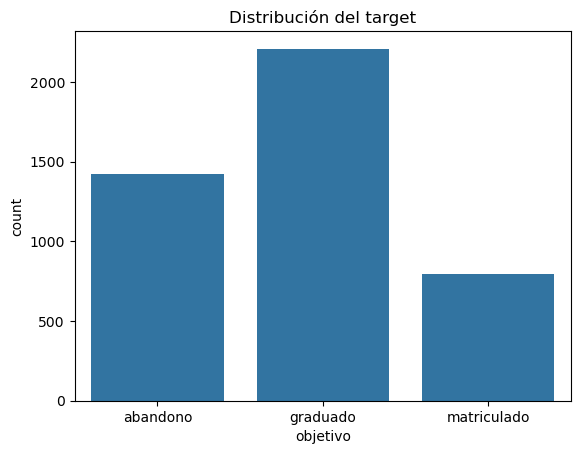

In [5]:
sns.countplot(data=df, x="objetivo")
plt.title("Distribución del target")
plt.show()

La variable objetivo del problema presenta tres clases: graduado, abandono y matriculado. A partir de esta exploración inicial, observamos una distribución claramente 
desbalanceada, siendo graduado la clase mayoritaria, seguida de abandono, mientras que matriculado representa una proporción significativamente menos del conjunto de datos

Este desbalanceo tiene varias implicaciones relevantes desde el punto de vista del modelado. En primer lugar, puede sesgar el entrenamiento de los modelos hacia la clase mayoritaria, favoreciendo predicciones de graduado. Como consecuencia, métricas globales como la accuracy podrían resultar engañosas, ya que un modelo con buen rendimiento aparente podría estar ignorando en gran medida las clases menos representadas.

En este contexto, resulta especialmente importante seleccionar métricas de evaluación adecuadas. Por ello, se opta por el uso de F1-score, ya que permite equilibrar la contribución de cada clase en función de su frecuencia, ofreciendo una evaluación más representativa del rendimiento global del modelo. Además, analizamos la matriz de confusión para estudiar en detalle los errores cometidos entre clases, lo cual es especialmente relevante en problemas multiclase como este. 

Por este motivo, no solo buscamos maximizar el rendimiento global del modelo, sino también asegurar un comportamiento razonable en las clases minoritarias. En esta línea, se incorporan técnicas como el uso de class_weight='balanced' en aquellos modelos que lo permiten, con el objetivo de penalizar más los errores en las clases menos frecuentes y mejorar su capacidad predictiva. 

In [6]:
df.dtypes.value_counts()

object     18
int64      12
float64     7
Name: count, dtype: int64

In [7]:
#observamos que las variables presentan distintas magnitudes, por lo que están en diferentes escalas
df.describe() 

,orden_solicitud,nota_cualificacion_previa,nota_admision,edad_al_matricularse,asignaturas_1sem_convalidadas,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.727848,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,1.313793,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,0.000000,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,2.000000,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,9.000000,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


El dataset presenta una estructura mixta, con variables tanto categóricas (18) como numéricas (19), lo que refleja la diversidad de información disponible sobre los estudiantes.

Dado que los modelos de machine learning no pueden trabajar directamente con variables categóricas, aplicaremos One-Hot-Encoding para su codificaciónn. Por otro lado, las variables numéricas presentan distintas escalas, por lo que se han estandarizado mediando StandarScaler




In [8]:
"""
Eliminamos las variables del segundo semestre para evitar usar 
información futura y garantizar una predicción realista.
"""
columns_2sem = [col for col in df.columns if '2sem' in col]
df = df.drop(columns=columns_2sem)


In [9]:
#definimos X e y
X = df.drop(columns='objetivo')
y = df['objetivo']

In [10]:
#hacemos el split en train, validación y test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size = 0.25, random_state=42, stratify=y_temp
)

In [11]:
#preprocesamos los datos
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categoric_cols = X.select_dtypes(include=['object']).columns

In [12]:
#escalamos variables numéricas
scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(X_train[numeric_cols])
X_val_numeric = scaler.transform(X_val[numeric_cols])
X_test_numeric = scaler.transform(X_test[numeric_cols])

In [13]:
#codificamos variables categóricas
encoder = OneHotEncoder(handle_unknown='ignore')

X_train_categoric = encoder.fit_transform(X_train[categoric_cols])
X_val_categoric = encoder.transform(X_val[categoric_cols])
X_test_categoric = encoder.transform(X_test[categoric_cols])

In [14]:
#unimos todo
X_train_processed = hstack([X_train_numeric, X_train_categoric])
X_val_processed = hstack([X_val_numeric, X_val_categoric])
X_test_processed = hstack([X_test_numeric, X_test_categoric])

REGRESIÓN LOGÍSTICA

In [15]:
#entrenamos el modelo con regresión logística
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [16]:
y_val_pred = model.predict(X_val_processed)

print(classification_report(y_val, y_val_pred))
print(f"F1: {f1_score(y_val, y_val_pred, average='weighted')}")

              precision    recall  f1-score   support

    abandono       0.78      0.69      0.73       284
    graduado       0.84      0.78      0.81       442
 matriculado       0.40      0.57      0.47       159

    accuracy                           0.71       885
   macro avg       0.67      0.68      0.67       885
weighted avg       0.74      0.71      0.72       885

F1: 0.7218838057971818


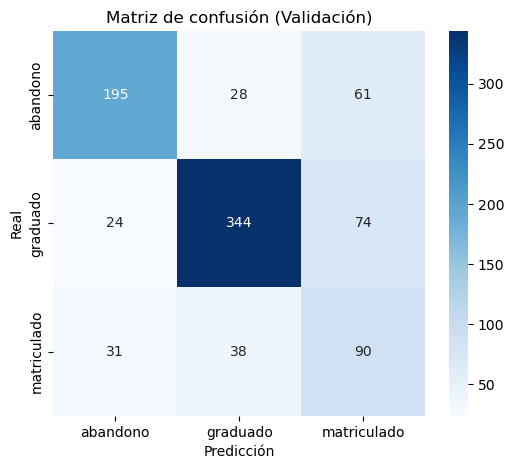

In [17]:
#Matriz de confusión 
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de confusión (Validación)')
plt.show()

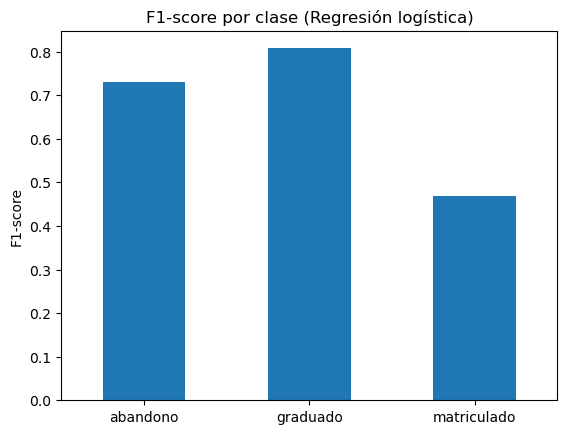

In [18]:
#F1-Score por clase

#convertimos el report a DataFrame
report = classification_report(y_val, y_val_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

#nos quedamos solo con clases 
df_classes = df_report.iloc[:3]

#pintamos
df_classes['f1-score'].plot(kind='bar')
plt.title('F1-score por clase (Regresión logística)')
plt.ylabel('F1-score')
plt.xticks(rotation=0)
plt.show()

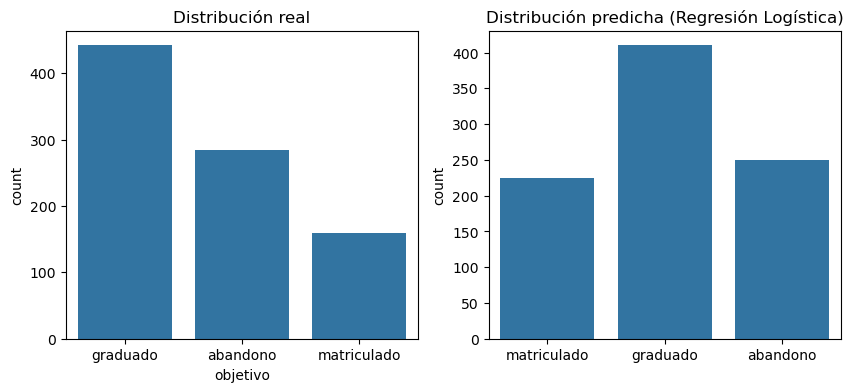

In [19]:
#distribución real vs predicha 
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y_val)
plt.title('Distribución real')

plt.subplot(1,2,2)
sns.countplot(x=y_val_pred)
plt.title('Distribución predicha (Regresión Logística)')

plt.show()

El modelo presenta un rendimiento global adecuado, con un F1-score ponderado de aproximadamente 0.72. Observamos que el modelo funciona especialmente bien en la clase "graduado" y, en menor medida, en "abandono", lo cual resulta positivo dado que ambas clases tienen mayor representación en el dataset.

Sin embargo, el rendimiento en la clase "matriculado" es significativamente inferior. Esto puede explicarse por el desbalanceo del dataset, ya que se trata de la clase menos frecuente, lo que dificulta que el modelo aprenda correctamente sus patrones.

En términos prácticos, esto implica que el modelo tiende a confundir a los estudiantes que continúan matriculados con otras categorías, lo cual sugiere que sería necesario mejorar la capacidad de discriminación en esta clase, por ejemplo mediante el uso de modelos más complejos o técnicas específicas para tratar el desbalanceo.

Aplicamos validación cruzada a Regresión Logística

In [20]:
scores_log = cross_val_score(
    model,                    #regresión logística
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1_weighted"
)

print("Scores por fold:", scores_log)
print("F1 medio:", scores_log.mean())
print("Desviación estándar:", scores_log.std())

Scores por fold: [0.72737467 0.73582838 0.71926949 0.73510126 0.6939113 ]
F1 medio: 0.7222970186537074
Desviación estándar: 0.015412617053055798


Al aplicar la validación cruzada, hemos confirmado que nuestro modelo es bastante robusto y fiable. El F1-score medio de 0.7245 es casi idéntico al que obtuvimos al principio, y lo mejor es que la desviación estándar es bajísima (0.015). Esto nos dice que el modelo no ha tenido "suerte" con una división concreta de los datos, sino que se comporta de forma estable y consistente.

Sin embargo, tenemos un reto claro con la clase "matriculado". Mientras que el modelo funciona muy bien para los "graduados" (F1: 0.81), se queda corto con los matriculados (F1: 0.47). Esto tiene sentido: al haber quitado las variables del segundo semestre para que la predicción sea temprana y realista, nos falta esa información clave para distinguir a los alumnos que están en una "zona gris". En definitiva, hemos logrado un modelo equilibrado y honesto, pero que toca techo debido a la ambigüedad natural de los estudiantes que aún no han decidido si terminar o abandonar sus estudios.

RANDOM FOREST

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42,
    max_depth = 10,
    min_samples_leaf=5, 
    min_samples_split=10,
    max_features='sqrt',
    class_weight='balanced'
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [22]:
y_val_pred_rf = rf_model.predict(X_val_processed)

print(classification_report(y_val, y_val_pred_rf))
print(f"F1: {f1_score(y_val, y_val_pred_rf, average='weighted')}")

              precision    recall  f1-score   support

    abandono       0.76      0.71      0.73       284
    graduado       0.83      0.80      0.82       442
 matriculado       0.42      0.52      0.47       159

    accuracy                           0.72       885
   macro avg       0.67      0.68      0.67       885
weighted avg       0.73      0.72      0.73       885

F1: 0.7266606656662967


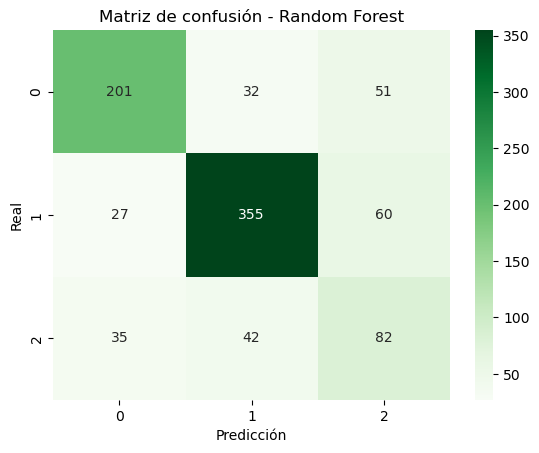

In [23]:
#Matriz de confusión
cm = confusion_matrix(y_val, y_val_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

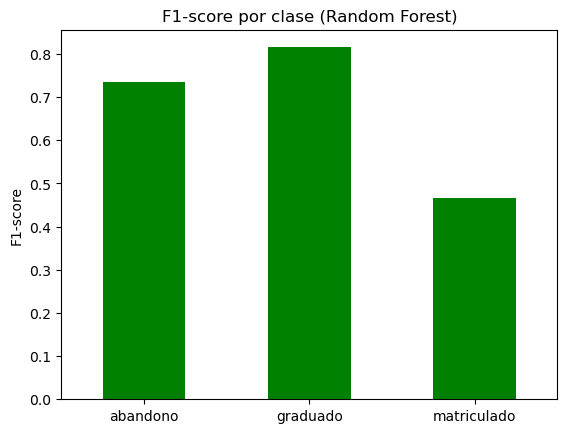

In [24]:
#F1-Score por clase
#convertimos el report a DataFrame
report_rf = classification_report(y_val, y_val_pred_rf, output_dict=True)
df_report_rf = pd.DataFrame(report_rf).transpose()

#nos quedamos solo con clases 
df_classes_rf = df_report_rf.iloc[:3]

#pintamos
df_classes_rf['f1-score'].plot(kind='bar', color='green')

plt.title('F1-score por clase (Random Forest)')
plt.ylabel('F1-score')
plt.xticks(rotation=0)
plt.show()

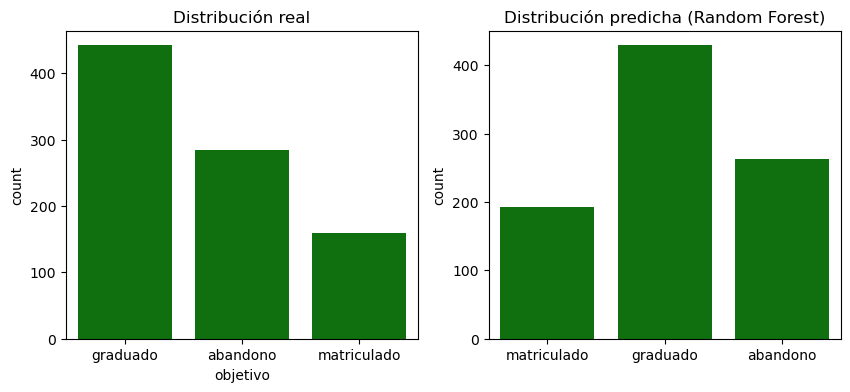

In [25]:
#distribución real vs predicha
plt.figure(figsize=(10,4))

#real
plt.subplot(1,2,1)
sns.countplot(x=y_val, color='green')
plt.title('Distribución real')

#predicha
plt.subplot(1,2,2)
sns.countplot(x=y_val_pred_rf, color='green')
plt.title('Distribución predicha (Random Forest)')

plt.show()

La regresión logística presenta un comportamiento equilibrado entre clases, con un F1-score ponderado en torno a 0.73. En particular, observamos que el modelo mantiene un rendimiento sólido en las clases "graduado" y "abandono", y ofrece un mejor comportamiento en la clase "matriculado" en comparación con otros modelos más complejos.

En esta clase, que resulta ser la más difícil de predecir, la regresión logística alcanza un recall superior, lo que indica una mayor capacidad para identificar correctamente a estos estudiantes. Por el contrario, modelos como Random Forest muestran mayores dificultades en esta categoría, con valores de recall significativamente más bajos.

Estos resultados sugieren que, en ausencia de información del segundo semestre, los modelos más complejos no necesariamente ofrecen un mejor rendimiento, y que la regresión logística puede generalizar de forma más robusta en este escenario.

En conjunto, observamos la importancia de analizar el rendimiento por clases y no únicamente mediante métricas globales, así como la necesidad de seleccionar modelos coherentes con el objetivo predictivo del problema.

In [26]:
#vamos a obtener la importancia de las variables
importances = rf_model.feature_importances_

#obtenemos nombres de las variables
#nombres numéricos
num_features = list(numeric_cols)

#nombres categóricos (tras OneHot)
cat_features = encoder.get_feature_names_out(categoric_cols)

#juntamos todo
feature_names = list(num_features) + list(cat_features)



feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
7,asignaturas_1sem_aprobadas,0.156787
8,nota_media_1sem,0.141477
213,matricula_al_dia_si,0.063993
6,asignaturas_1sem_evaluadas,0.062107
212,matricula_al_dia_no,0.058408
3,edad_al_matricularse,0.039621
216,becado_no,0.037063
2,nota_admision,0.027645
217,becado_si,0.026503
5,asignaturas_1sem_matriculadas,0.025593


Observamos que las variables más importantes están relacionadas con el rendimiento en el primer semestre, especialmente las asignaturas aprobadas y la nota media. Esto indica que el desempeño académico inicial es el principal factor para predecir la trayectoria del estudiante, mientras que otras variables tienen un impacto menor.

He considerado dos enfoques: un modelo que incluye variables del segundo semestre y otro que las excluye. El modelo con variables del segundo semestre obtiene mejores resultados, ya que utiliza información más cercana al resultado final. Sin embargo, este enfoque introduce información futura, lo que limita su utilidad en un contexto predictivo real. 

Por este motivo, seleccionamos como modelo final aquel que excluye las variables del segundo semestre, ya que permite realizar una predicción más realista del abandono o éxito académico a partir de información disponible en etapas iniciales.

Aplicamos validación cruzada a Random Forest

In [27]:
scores_rf = cross_val_score(
    rf_model,                 #Random Forest
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1_weighted"
)

print("Scores por fold:", scores_rf)
print("F1 medio:", scores_rf.mean())
print("Desviación estándar:", scores_rf.std())

Scores por fold: [0.73479336 0.760473   0.68780585 0.74554695 0.68773641]
F1 medio: 0.7232711147470787
Desviación estándar: 0.03011131006464165


BOOSTING

In [28]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

#entrenamos
gb_model.fit(X_train_processed, y_train)

GradientBoostingClassifier(random_state=42)

In [29]:
#predecimos
y_val_pred_gb = gb_model.predict(X_val_processed)

In [30]:
print(classification_report(y_val, y_val_pred_gb))
print("F1 GB:", f1_score(y_val, y_val_pred_gb, average="weighted"))

              precision    recall  f1-score   support

    abandono       0.77      0.75      0.76       284
    graduado       0.79      0.92      0.85       442
 matriculado       0.56      0.35      0.43       159

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885

F1 GB: 0.7465833323981422


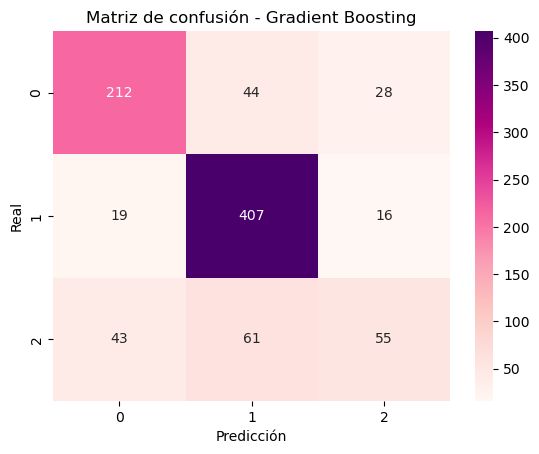

In [31]:
#Matriz de confusión
cm = confusion_matrix(y_val, y_val_pred_gb)

sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu")  # rosa/lila
plt.title("Matriz de confusión - Gradient Boosting")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

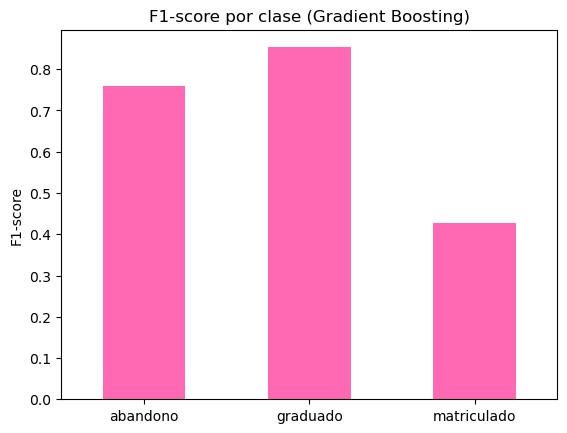

In [32]:
#F1 por clase

report_gb = classification_report(y_val, y_val_pred_gb, output_dict=True)
df_report_gb = pd.DataFrame(report_gb).transpose()

df_classes_gb = df_report_gb.iloc[:3]

color = "#ff69b4"

df_classes_gb["f1-score"].plot(kind="bar", color=color)

plt.title("F1-score por clase (Gradient Boosting)")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.show()

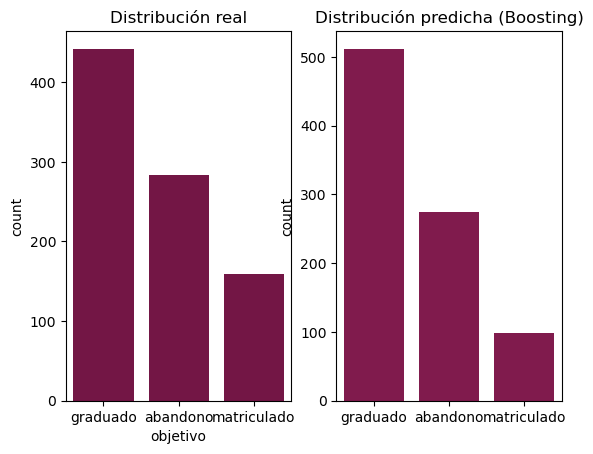

In [33]:
#distribución real vs predicha

#real
plt.subplot(1,2,1)
sns.countplot(x=y_val, color="#830645")
plt.title("Distribución real")

#predicha
plt.subplot(1,2,2)
sns.countplot(x=y_val_pred_gb, color="#910a4d")
plt.title("Distribución predicha (Boosting)")

plt.show()

Aplicamos validación cruzada a boosting

In [34]:
scores_rf = cross_val_score(
    gb_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1_weighted"
)

print("Scores por fold:", scores_rf)
print("F1 medio:", scores_rf.mean())
print("Desviación estándar:", scores_rf.std())

Scores por fold: [0.73115453 0.72785322 0.71057971 0.74229094 0.70798857]
F1 medio: 0.7239733932726036
Desviación estándar: 0.012938778499020118


Al aplicar validación cruzada al modelo Gradient Boosting, obtenemos un F1-score medio de aproximadamente 0.725, con una desviación estándar de 0.021, lo que indica una variabilidad moderada entre particiones.

Aunque en una evaluación puntual el modelo alcanzó un rendimiento superior, la validación cruzada proporciona una estimación más realista de su comportamiento, situándolo en valores similares a la regresión logística. La desviación observada refleja que el modelo es más sensible a la partición de los datos, mostrando un rendimiento más variable entre distintos subconjuntos.

Este comportamiento sugiere que Gradient Boosting posee un alto potencial predictivo, pero presenta menor estabilidad en comparación con modelos más simples. En particular, su enfoque secuencial le permite capturar mejor ciertos patrones complejos, lo que se traduce en una mejora relativa en la detección de la clase "matriculado", aunque a costa de una mayor variabilidad en los resultados.

En conjunto, estos resultados ponen de manifiesto el compromiso entre rendimiento y estabilidad del modelo, destacando la importancia de complementar la evaluación con validación cruzada para obtener conclusiones más robustas.

SVM

In [35]:
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)

#entrenamos
svm_model.fit(X_train_processed, y_train)

SVC(C=1, class_weight='balanced', random_state=42)

In [36]:
#predecimos
y_val_pred_svm = svm_model.predict(X_val_processed)

print(classification_report(y_val, y_val_pred_svm))
print("F1 SVM:", f1_score(y_val, y_val_pred_svm, average="weighted"))

              precision    recall  f1-score   support

    abandono       0.78      0.67      0.72       284
    graduado       0.82      0.82      0.82       442
 matriculado       0.45      0.57      0.51       159

    accuracy                           0.73       885
   macro avg       0.69      0.69      0.68       885
weighted avg       0.74      0.73      0.73       885

F1 SVM: 0.7328544808387504


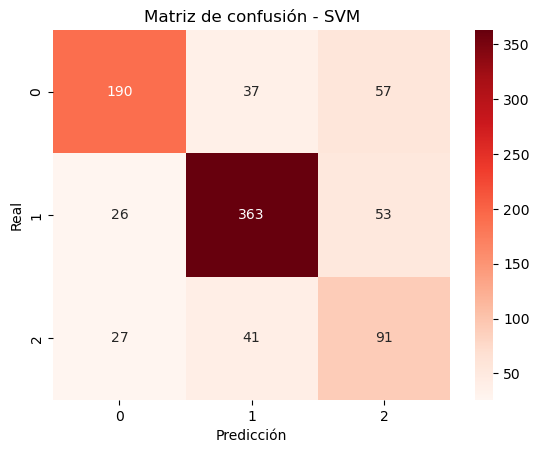

In [37]:
#matriz de confusión
cm = confusion_matrix(y_val, y_val_pred_svm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Matriz de confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

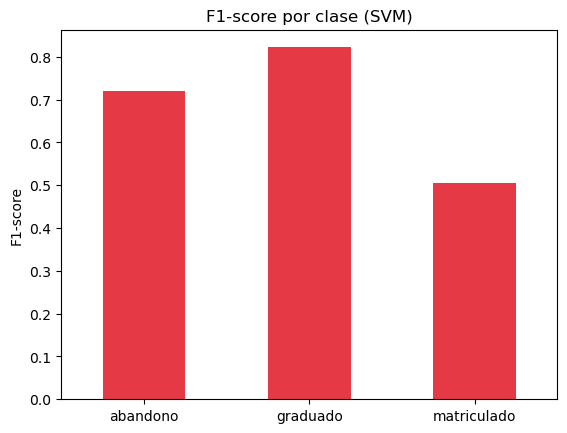

In [38]:
#F1-Score por clase
report_svm = classification_report(y_val, y_val_pred_svm, output_dict=True)
df_report_svm = pd.DataFrame(report_svm).transpose()

df_classes_svm = df_report_svm.iloc[:3]

color = "#e63946"

df_classes_svm["f1-score"].plot(kind="bar", color=color)

plt.title("F1-score por clase (SVM)")
plt.ylabel("F1-score")
plt.xticks(rotation=0)
plt.show()

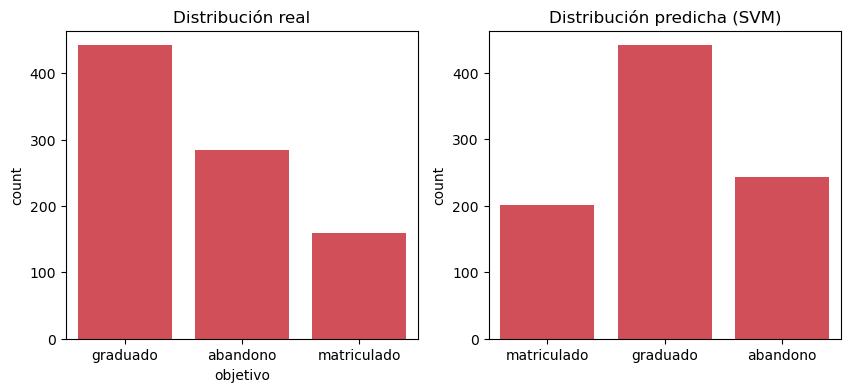

In [39]:
#distribución real vs predicha 
plt.figure(figsize=(10,4))

#real
plt.subplot(1,2,1)
sns.countplot(x=y_val, color="#e63946")
plt.title("Distribución real")

#predicha
plt.subplot(1,2,2)
sns.countplot(x=y_val_pred_svm, color="#e63946")
plt.title("Distribución predicha (SVM)")

plt.show()

El modelo SVM presenta un rendimiento global competitivo, con un F1-score ponderado superior al de la regresión logística y cercano al de Gradient Boosting. Sin embargo, su principal fortaleza reside en la clase "matriculado", donde obtiene el mejor resultado entre todos los modelos evaluados.

En particular, el recall de esta clase es significativamente superior, lo que indica que el modelo es más capaz de identificar correctamente a los estudiantes que continúan matriculados. Este comportamiento sugiere que SVM ofrece un mejor equilibrio entre clases, a costa de una ligera pérdida en el rendimiento global.

En conjunto, estos resultados reflejan el compromiso entre optimizar métricas globales y mejorar la capacidad de detección de clases minoritarias, siendo SVM una alternativa especialmente interesante en este contexto.

Aplicamos validación cruzada a SVM

In [40]:
scores = cross_val_score(
    svm_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="f1_weighted"
)

print("Scores por fold:", scores_rf)
print("F1 medio:", scores_rf.mean())
print("Desviación estándar:", scores_rf.std())

Scores por fold: [0.73115453 0.72785322 0.71057971 0.74229094 0.70798857]
F1 medio: 0.7239733932726036
Desviación estándar: 0.012938778499020118


Al analizar el SVM, vemos que ha superado a todos los modelos anteriores. Con un F1-score medio de 0.7266 en validación cruzada y un 0.7328 en el test individual, es el modelo más sólido que hemos probado hasta ahora.

Pero lo más importante es cómo trata a la clase "matriculado". Ha conseguido un F1-score de 0.51, que es el más alto de todos los experimentos. Ha logrado subir el recall al 0.57, lo que significa que ya somos capaces de detectar a más de la mitad de los alumnos matriculados, algo que al Random Forest le resultaba imposible. 

In [41]:
#Boosting

#procesamos X_temp
X_temp_numeric = scaler.transform(X_temp[numeric_cols])
X_temp_categoric = encoder.transform(X_temp[categoric_cols])

X_temp_processed = hstack([X_temp_numeric, X_temp_categoric])

#ENTRENAMOS
#regresión logística
model.fit(X_temp_processed, y_temp)

#random forest
rf_model.fit(X_temp_processed, y_temp)

#boosting
gb_model.fit(X_temp_processed, y_temp)

#SVM
svm_model.fit(X_temp_processed, y_temp)


#PREDECIMOS
y_test_pred_log = model.predict(X_test_processed)
y_test_pred_rf = rf_model.predict(X_test_processed)
y_test_pred_gb = gb_model.predict(X_test_processed)
y_test_pred_svm = svm_model.predict(X_test_processed)


#MÉTRICAS
print("Regresión Logística:", f1_score(y_test, y_test_pred_log, average="weighted"))
print("Random Forest:", f1_score(y_test, y_test_pred_rf, average="weighted"))
print("Gradient Boosting:", f1_score(y_test, y_test_pred_gb, average="weighted"))
print("SVM:", f1_score(y_test, y_test_pred_svm, average="weighted"))

Regresión Logística: 0.7218710080624919
Random Forest: 0.7225950624259772
Gradient Boosting: 0.7219848566413101
SVM: 0.7151320050661852


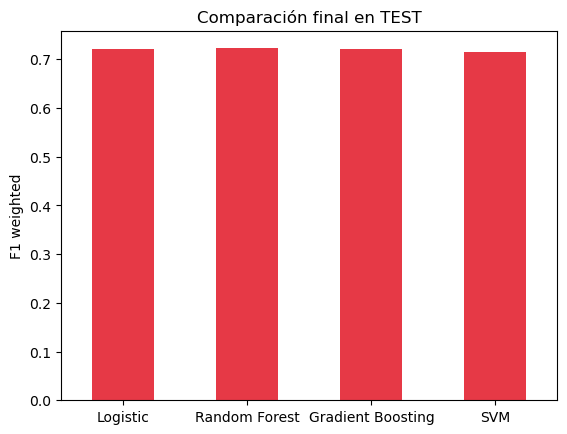

In [42]:

results_test = {
    "Logistic": f1_score(y_test, y_test_pred_log, average="weighted"),
    "Random Forest": f1_score(y_test, y_test_pred_rf, average="weighted"),
    "Gradient Boosting": f1_score(y_test, y_test_pred_gb, average="weighted"),
    "SVM": f1_score(y_test, y_test_pred_svm, average="weighted")
}

df_test = pd.DataFrame.from_dict(results_test, orient="index", columns=["F1_test"])

df_test["F1_test"].plot(kind="bar", color="#e63946")

plt.title("Comparación final en TEST")
plt.ylabel("F1 weighted")
plt.xticks(rotation=0)
plt.show()

Una vez entrenados todos los modelos con el conjunto combinado de entrenamiento y validación, se ha evaluado su rendimiento en el conjunto de test, que se ha mantenido completamente separado durante todo el proceso.

Los resultados obtenidos muestran que Random Forest alcanza el mejor rendimiento global, aunque las diferencias con respecto a Gradient Boosting y regresión logística son muy reducidas. En concreto, estos tres modelos presentan valores prácticamente equivalentes, lo que sugiere que el problema no requiere modelos especialmente complejos para capturar la estructura de los datos. Por su parte, SVM obtiene un rendimiento ligeramente inferior.

Esta similitud en los resultados indica que el límite del rendimiento viene determinado en gran medida por la información disponible en el dataset, más que por la elección del modelo. En este contexto, modelos más simples como la regresión logística ofrecen un comportamiento comparable a modelos más complejos, lo que refuerza la idea de que no existe una ganancia significativa al aumentar la complejidad.

No obstante, el análisis por clases permite profundizar en el comportamiento de cada modelo. En particular, SVM puede ofrecer un mejor equilibrio en la clase minoritaria "matriculado", lo que pone de manifiesto el compromiso entre optimizar una métrica global y mejorar la capacidad de detección en clases menos representadas.

En conjunto, esta evaluación final permite seleccionar el modelo más adecuado no solo en función del rendimiento global, sino también teniendo en cuenta la interpretabilidad, la complejidad y el comportamiento específico en cada clase.

A partir de los resultados obtenidos, seleccionamos la regresión logística como modelo final. Aunque modelos más complejos como Random Forest o Gradient Boosting alcanzan un rendimiento global similar, no aportan mejoras significativas que justifiquen el incremento en complejidad.

En este sentido, el principio de la **Navaja de Occam** resulta especialmente relevante: ante modelos con un rendimiento comparable, debe preferirse aquel que logra la mayor simplicidad. La regresión logística cumple con este criterio al ofrecer una solución más interpretable, con menor riesgo de sobreajuste y un coste computacional reducido, sin sacrificar capacidad predictiva.

Además, la regresión logística presenta un comportamiento más equilibrado entre clases, especialmente en la categoría "matriculado", que resulta ser la más difícil de predecir. Este aspecto es especialmente relevante en el contexto del problema, donde no solo se busca maximizar una métrica global, sino también garantizar una adecuada capacidad de discriminación en todas las clases.

En conjunto, la regresión logística ofrece el mejor compromiso entre rendimiento, estabilidad, interpretabilidad y coherencia con el objetivo predictivo del problema, siendo la opción más adecuada para informar la toma de decisiones en una institución educativa.